# Analyst-Forecast-Based Equity Duration (FcstD)

This notebook computes equity duration based on analyst consensus forecasts
(EPS, DPS) for Euro Stoxx 500 firms.

Earnings projection follows Gebhardt et al. (2001) and Schröder & Esterer (2016):
analyst EPS forecasts for h=1..3, ROE reversion to trailing industry ROE for h=4..10,
book equity compounded via clean surplus.

Duration is a weighted-average maturity (WAM) with common discount rate r=0.12
(Dechow, Sloan & Soliman 2004), ensuring cross-sectional variation reflects
cash-flow timing rather than discount-rate levels.

## 0. Setup

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from plot_style import COLORS, set_global_plot_style, style_axes, save_figure as _ps_save_figure

set_global_plot_style()

from project_paths import BASE_DIR, DATA_DIR, GRAPH_DIR

def save_parquet(df: pd.DataFrame, name: str):
    path = DATA_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved: {path}")

def load_parquet(name: str) -> pd.DataFrame:
    path = DATA_DIR / f"{name}.parquet"
    return pd.read_parquet(path)

NOTEBOOK_GRAPH_DIR = GRAPH_DIR / "EQDuration_AnalystBased"
NOTEBOOK_GRAPH_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name: str):
    path = NOTEBOOK_GRAPH_DIR / f"{name}.png"
    _ps_save_figure(fig, path, dpi=220)
    print(f"Saved figure: {path}")

## 1. Load Data

We load the analyst-based panel (`euro500_analystbased.parquet`) and the
net-payout duration output (`EQDuration_Netpayout.parquet`) for cross-validation.

In [74]:
raw = load_parquet("euro500_analystbased")
print(f"Loaded euro500_analystbased: {raw.shape[0]:,} rows, {raw.shape[1]} cols")
print(f"Firms: {raw['firm_id'].nunique():,}  |  Date range: {raw['date'].min()} – {raw['date'].max()}")

# Discount rate panel for Jensen corrections
np_out = load_parquet("EQDuration_Netpayout")
print(f"\nLoaded EQDuration_Netpayout: {np_out.shape[0]:,} rows")

Loaded euro500_analystbased: 13,500 rows, 23 cols
Firms: 1,094  |  Date range: 1998-12-31 00:00:00 – 2024-12-31 00:00:00

Loaded EQDuration_Netpayout: 12,073 rows


## 2. Sample Restrictions

Sequential filters: post-1998 (I/B/E/S coverage), positive book equity,
positive market equity, at least FY1 Cash EPS forecast available.

In [75]:
df = raw.copy()
df["year"] = df["date"].dt.year

n0 = len(df)
funnel = [("Raw input", n0)]

# 1) Drop years before 1998
df = df[df["year"] >= 1998].copy()
n1 = len(df)
funnel.append(("year >= 1998", n1))
print(f"Filter 1 (year >= 1998): {n0 - n1:,} dropped, {n1:,} remaining")

# 2) NumAnalysts_fy1 >= 3
df = df[df["NumAnalysts_fy1"] >= 3].copy()
n2 = len(df)
funnel.append(("NumAnalysts_fy1 >= 3", n2))
print(f"Filter 2 (NumAnalysts >= 3): {n1 - n2:,} dropped, {n2:,} remaining")

# 3) EPS_fy1_est not NaN (primary input for duration)
df = df[df["EPS_fy1_est"].notna()].copy()
n3 = len(df)
funnel.append(("EPS_fy1_est not NaN", n3))
print(f"Filter 3 (EPS_fy1 not NaN): {n2 - n3:,} dropped, {n3:,} remaining")

# 4) BE > 0, ME > 0, shares_outstanding > 0
df = df[(df["BE"] > 0) & (df["ME"] > 0) & (df["shares_outstanding"] > 0)].copy()
n4 = len(df)
funnel.append(("BE > 0 & ME > 0 & shares > 0", n4))
print(f"Filter 4 (positive BE/ME/shares): {n3 - n4:,} dropped, {n4:,} remaining")

# 5) S&E: exclude if FY2 or FY3 earnings forecast is negative
has_neg_fy2 = (df["EPS_fy2_est"] * df["shares_outstanding"]) < 0
has_neg_fy3 = (df["EPS_fy3_est"] * df["shares_outstanding"]) < 0
n_before = len(df)
df = df[~(has_neg_fy2.fillna(False) | has_neg_fy3.fillna(False))].copy()
n5 = len(df)
funnel.append(("FY2/FY3 not negative", n5))
print(f"Filter 5 (Negative FY2/FY3): {n_before - n5:,} dropped, {n5:,} remaining")

print(f"\nFinal sample: {n5:,} firm-years, {df['firm_id'].nunique():,} unique firms")

# Funnel table
funnel_df = pd.DataFrame(funnel, columns=["Step", "Firm-years"])
funnel_df["Dropped"] = funnel_df["Firm-years"].diff().fillna(0).astype(int) * -1
funnel_df.loc[0, "Dropped"] = 0
print("\n" + funnel_df.to_string(index=False))


Filter 1 (year >= 1998): 0 dropped, 13,500 remaining
Filter 2 (NumAnalysts >= 3): 2,227 dropped, 11,273 remaining
Filter 3 (EPS_fy1 not NaN): 4 dropped, 11,269 remaining
Filter 4 (positive BE/ME/shares): 267 dropped, 11,002 remaining
Filter 5 (Negative FY2/FY3): 189 dropped, 10,813 remaining

Final sample: 10,813 firm-years, 836 unique firms

                        Step  Firm-years  Dropped
                   Raw input       13500        0
                year >= 1998       13500        0
        NumAnalysts_fy1 >= 3       11273     2227
         EPS_fy1_est not NaN       11269        4
BE > 0 & ME > 0 & shares > 0       11002      267
        FY2/FY3 not negative       10813      189


## 3. Industry ROE

Trailing 5-year trimmed mean ROE by TRBC sector, following Schröder & Esterer (2012).
Lowest/highest 1% of realized ROE removed before computing sector means.
Industry ROE floored at 0.5% and capped at 50%.


In [76]:
# 3a. Verify trbc_sector availability
print(f"trbc_sector coverage: {df['trbc_sector'].notna().sum()} / {len(df)} "
      f"({df['trbc_sector'].notna().mean():.1%})")
print(df["trbc_sector"].value_counts())

# 3b. Compute current ROE proxy from FY1 analyst forecasts
df["ROE_current"] = (df["EPS_fy1_est"] * df["shares_outstanding"]) / df["BE"]

# 3c. Trailing 5-year TRIMMED MEAN ROE by TRBC sector (S&E 2012)
# S&E: "the lowest and highest centile of all realized roe are removed
# prior to the industry roe estimation"
roe_for_industry = df[["firm_id", "year", "trbc_sector", "ROE_current"]].copy()

def trimmed_mean(x):
    """Trim 1st/99th percentile within group, then take mean."""
    q01 = x.quantile(0.01)
    q99 = x.quantile(0.99)
    trimmed = x[(x >= q01) & (x <= q99)]
    return trimmed.mean() if len(trimmed) > 0 else x.mean()

industry_roe = {}
for year in sorted(df["year"].unique()):
    window = roe_for_industry[
        (roe_for_industry["year"] >= year - 4) &
        (roe_for_industry["year"] <= year)
    ]
    means = window.groupby("trbc_sector")["ROE_current"].apply(trimmed_mean)
    for sector, mean_roe in means.items():
        # S&E: negative industry ROE replaced with 0.5%, cap at 50%
        if mean_roe < 0:
            mean_roe = 0.005
        elif mean_roe > 0.50:
            mean_roe = 0.50
        industry_roe[(sector, year)] = mean_roe

df["industry_roe"] = df.apply(
    lambda row: industry_roe.get((row["trbc_sector"], row["year"]), np.nan),
    axis=1,
)

# 3d. Handle edge cases
# Fallback: if industry_roe is NaN, use cross-sectional mean for that year
year_means = df.groupby("year")["industry_roe"].transform("mean")
df["industry_roe"] = df["industry_roe"].fillna(year_means)

# Floor negative industry ROE at 0.5%
df.loc[df["industry_roe"] < 0.005, "industry_roe"] = 0.005
# Cap at 50%
df.loc[df["industry_roe"] > 0.50, "industry_roe"] = 0.50

print(f"\nindustry_roe coverage: {df['industry_roe'].notna().sum()} / {len(df)}")
print(f"industry_roe NaN remaining: {df['industry_roe'].isna().sum()}")

# 3e. Diagnostic table
print("\nIndustry ROE (trailing 5-year trimmed mean):")
diag = df.groupby("trbc_sector")["industry_roe"].agg(
    ["mean", "median", "min", "max", "count"]
)
diag.columns = ["Mean", "Median", "Min", "Max", "N_firm_years"]
diag = diag.sort_values("N_firm_years", ascending=False)
print(diag.to_string(float_format=lambda x: f"{x:.3f}" if x < 10 else f"{x:.0f}"))


trbc_sector coverage: 10813 / 10813 (100.0%)
trbc_sector
Industrials                                   2163
Consumer Cyclicals                            1679
Financials                                    1423
Technology                                    1241
Basic Materials                               1184
Consumer Non-Cyclicals                         802
Healthcare                                     746
Utilities                                      605
Energy                                         500
Real Estate                                    467
Institutions, Associations & Organizations       3
Name: count, dtype: Int64

industry_roe coverage: 10813 / 10813
industry_roe NaN remaining: 0

Industry ROE (trailing 5-year trimmed mean):
                                            Mean  Median   Min   Max  N_firm_years
trbc_sector                                                                       
Industrials                                0.149   0.151 0.118 0.193        

## 4. Duration Construction

Earnings projection: EPS analyst forecasts (h=1..3) → ROE reversion to 
trailing industry mean (Gebhardt et al. 2001, h=4..10) → steady-state at 
industry ROE (h=11..20). Clean surplus book equity compounding. Payout ratio 
fades linearly from current level to 50%.

Duration: Weighted-Average Maturity (WAM) with common discount rate 
r = 0.08 and residual terminal value at h=20.

In [77]:
# Constants
H_EXPLICIT = 3      # analyst forecast horizon (FY1, FY2, FY3)
H_TRANSITION = 17    # transition years (h=4..20)
H_CONVERGED = 10    # steady-state years (h=21..30)
H_TOTAL = H_EXPLICIT + H_TRANSITION + H_CONVERGED  # = 30
R_COMMON = 0.12     # common discount rate
ROE_CAP = 1.0       # cap extreme ROE


def compute_fcstd(row):
    """
    Analyst-forecast-based equity duration (Cash-Flow Maturity).

    Earnings projection: EPS analyst forecasts (h=1..3) with linear ROE
    reversion to trailing industry mean ROE (Gebhardt et al. 2001) over
    h=4..10, then steady-state at industry ROE for h=11..20. Book equity
    compounded via additive clean surplus. Payout ratio fades linearly
    from current level to 50%.

    Duration: Weighted-Average Maturity (Definition 1) with common
    discount rate r and residual terminal value.
    """
    BE_t = float(row["BE"])
    ME = float(row["ME"])
    shares = float(row["shares_outstanding"])
    roe_target = float(row["industry_roe"])

    nan_return = {
        "ROE_fy1": np.nan, "ROE_fy2": np.nan, "ROE_fy3": np.nan,
        "b_fy1": np.nan, "b_fy2": np.nan, "b_fy3": np.nan,
        "industry_roe_used": np.nan,
        "PV_forecast": np.nan, "TV": np.nan,
        "Duration_FcstD_raw": np.nan,
    }

    if pd.isna(roe_target):
        return nan_return

    # ── Analyst inputs + FY3 fallback ───────────────────────
    eps = [row["EPS_fy1_est"], row["EPS_fy2_est"], row["EPS_fy3_est"]]
    dps = [row["DPS_fy1_est"], row["DPS_fy2_est"], row["DPS_fy3_est"]]
    ltg = row.get("LTG_est", np.nan)

    E = [c * shares if pd.notna(c) else np.nan for c in eps]

    # FY3 fallback via LTG (S&E Appendix A)
    if pd.isna(E[2]) and pd.notna(E[1]) and pd.notna(ltg):
        E[2] = E[1] * (1.0 + ltg)

    # Exclude if FY2 or FY3 negative (S&E)
    if pd.notna(E[1]) and E[1] < 0:
        return nan_return
    if pd.notna(E[2]) and E[2] < 0:
        return nan_return

    # ── Payout ratio fade ───────────────────────────────────
    if pd.notna(dps[0]) and pd.notna(E[0]) and E[0] > 0:
        p_current = np.clip((dps[0] * shares) / E[0], 0.0, 1.0)
    else:
        p_current = 0.5

    P_LONG = 0.5
    T_FADE = H_EXPLICIT + H_TRANSITION  # = 10, payout reaches 50% at h=10

    def payout_at(h):
        fade = min(h / T_FADE, 1.0)
        return p_current + (P_LONG - p_current) * fade

    # ── Sequential forward pass ─────────────────────────────
    ROE_path = []
    B_start = []
    b_payout = []

    BE_prev = BE_t

    # Stage 1: Explicit forecasts (h=1..3)
    for h in range(1, H_EXPLICIT + 1):
        B_start.append(BE_prev)
        h_idx = h - 1

        if pd.notna(E[h_idx]) and BE_prev > 0:
            roe_h = np.clip(E[h_idx] / BE_prev, -ROE_CAP, ROE_CAP)
        else:
            roe_h = np.nan
        ROE_path.append(roe_h)

        p_h = payout_at(h)
        b_payout.append(p_h)

        if pd.notna(E[h_idx]):
            BE_prev = BE_prev + E[h_idx] * (1.0 - p_h)
            if BE_prev < 0:
                BE_prev = 0.01

    # Stage 2: Transition (h=4..10)
    ROE_last = next(
        (ROE_path[i] for i in reversed(range(H_EXPLICIT))
         if pd.notna(ROE_path[i])),
        roe_target,
    )

    for h in range(H_EXPLICIT + 1, H_EXPLICIT + H_TRANSITION + 1):
        B_start.append(BE_prev)

        alpha_h = (h - H_EXPLICIT) / H_TRANSITION
        roe_h = ROE_last * (1.0 - alpha_h) + roe_target * alpha_h
        ROE_path.append(roe_h)

        p_h = payout_at(h)
        b_payout.append(p_h)

        earnings_h = roe_h * BE_prev
        BE_prev = BE_prev + earnings_h * (1.0 - p_h)
        if BE_prev < 0:
            BE_prev = 0.01

    # Stage 3: Steady-state (h=11..20)
    for h in range(H_EXPLICIT + H_TRANSITION + 1, H_TOTAL + 1):
        B_start.append(BE_prev)

        roe_h = roe_target
        ROE_path.append(roe_h)

        p_h = P_LONG  # payout already at 50%
        b_payout.append(p_h)

        earnings_h = roe_h * BE_prev
        BE_prev = BE_prev + earnings_h * (1.0 - p_h)
        if BE_prev < 0:
            BE_prev = 0.01

    # ── Cash Flows ──────────────────────────────────────────
    CF = []
    for h_idx in range(H_TOTAL):
        roe_h = ROE_path[h_idx]
        b_h = B_start[h_idx]
        p_h = b_payout[h_idx]
        if pd.notna(roe_h) and b_h > 0:
            CF.append(roe_h * b_h * p_h)
        else:
            CF.append(np.nan)

    # ── Discount and WAM Duration ───────────────────────────
    r = R_COMMON
    disc = [1.0 / (1.0 + r) ** h for h in range(1, H_TOTAL + 1)]

    PV_forecast = sum(
        CF[i] * disc[i] for i in range(H_TOTAL) if pd.notna(CF[i])
    )
    TV = max(ME - PV_forecast, 0.0)

    # Duration over explicit CFs only, normalized by PV_forecast
    numerator = sum(
        (i + 1) * CF[i] * disc[i]
        for i in range(H_TOTAL) if pd.notna(CF[i])
    )

    Duration_raw = numerator / PV_forecast if PV_forecast > 0 else np.nan

    return {
        "ROE_fy1": ROE_path[0] if len(ROE_path) > 0 else np.nan,
        "ROE_fy2": ROE_path[1] if len(ROE_path) > 1 else np.nan,
        "ROE_fy3": ROE_path[2] if len(ROE_path) > 2 else np.nan,
        "b_fy1": b_payout[0], "b_fy2": b_payout[1], "b_fy3": b_payout[2],
        "industry_roe_used": roe_target,
        "PV_forecast": PV_forecast,
        "TV": TV,
        "Duration_FcstD_raw": Duration_raw,
    }


# ===== Apply to panel =====

print(f"Computing FcstD (WAM, r={R_COMMON}) for {len(df):,} firm-years ...")
results = df.apply(compute_fcstd, axis=1, result_type="expand")
df = pd.concat([df, results], axis=1)
print("Done.")

# Stats
valid = df["Duration_FcstD_raw"].notna()
n_valid = valid.sum()
print(f"\nValid: {n_valid:,} / {len(df):,} ({n_valid/len(df):.1%})")

dur = df.loc[valid, "Duration_FcstD_raw"]
print(f"\nDuration_FcstD_raw (valid):")
print(dur.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

Computing FcstD (WAM, r=0.12) for 10,813 firm-years ...
Done.

Valid: 10,811 / 10,813 (100.0%)

Duration_FcstD_raw (valid):
count    10811.000000
mean        14.451333
std          3.837196
min          5.006228
1%           5.927281
5%           8.725457
25%         11.857601
50%         14.125434
75%         16.797029
95%         22.125212
99%         23.732487
max         24.408323
Name: Duration_FcstD_raw, dtype: float64


## 5. Winsorization

Duration is winsorized at the 1st and 99th percentiles.

In [78]:
# Yearly winsorization at P1/P99 (not forward-looking)
df["Duration_FcstD"] = df["Duration_FcstD_raw"].copy()

bounds = []
for yr, grp in df.loc[df["Duration_FcstD_raw"].notna()].groupby("year"):
    p1 = grp["Duration_FcstD_raw"].quantile(0.01)
    p99 = grp["Duration_FcstD_raw"].quantile(0.99)
    mask = (df["year"] == yr) & df["Duration_FcstD"].notna()
    df.loc[mask, "Duration_FcstD"] = df.loc[mask, "Duration_FcstD"].clip(lower=p1, upper=p99)
    bounds.append({"year": yr, "P1": p1, "P99": p99, "n": grp.shape[0]})

bounds_df = pd.DataFrame(bounds)
print("Yearly winsorization bounds (P1/P99):")
print(bounds_df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

usable = df["Duration_FcstD"].notna()
print(f"\nValid: {usable.sum():,} / {len(df):,}")
print(f"Mean: {df.loc[usable, 'Duration_FcstD'].mean():.2f}, "
      f"Std: {df.loc[usable, 'Duration_FcstD'].std():.2f}")

Yearly winsorization bounds (P1/P99):
 year   P1   P99   n
 1998 8.89 19.31 283
 1999 8.81 20.48 308
 2000 9.06 21.88 317
 2001 9.00 20.06 325
 2002 9.17 20.81 329
 2003 8.85 19.75 347
 2004 8.34 20.32 357
 2005 9.03 21.49 377
 2006 9.39 23.63 394
 2007 9.37 23.61 423
 2008 9.21 23.91 402
 2009 9.28 24.01 410
 2010 5.36 24.19 436
 2011 5.32 24.30 420
 2012 5.28 24.06 415
 2013 8.22 24.25 425
 2014 5.71 23.78 428
 2015 5.72 23.77 441
 2016 5.53 23.77 444
 2017 5.56 23.74 447
 2018 6.66 23.61 439
 2019 7.65 23.74 443
 2020 8.06 21.13 435
 2021 8.19 20.89 446
 2022 8.04 19.73 442
 2023 7.85 19.00 438
 2024 7.88 18.93 440

Valid: 10,811 / 10,813
Mean: 14.45, Std: 3.82


## 6. Save Output

In [79]:
out_cols = [
    "firm_id", "date", "year", "trbc_sector",
    "EPS_fy1_est", "EPS_fy2_est", "EPS_fy3_est",
    "DPS_fy1_est", "DPS_fy2_est", "DPS_fy3_est",
    "NumAnalysts_fy1",
    "shares_outstanding", "BE", "ME",
    "ROE_fy1", "ROE_fy2", "ROE_fy3",
    "b_fy1", "b_fy2", "b_fy3",
    "industry_roe_used",
    "PV_forecast", "TV",
    "Duration_FcstD_raw", "Duration_FcstD",
]

out = df[out_cols].copy().sort_values(["firm_id", "date"]).reset_index(drop=True)

save_parquet(out, "EQDuration_Fcst")

print(f"\nOutput shape: {out.shape}")
print(f"Unique firms: {out['firm_id'].nunique():,}")
print(f"Year range: {out['date'].dt.year.min()} \u2013 {out['date'].dt.year.max()}")
print(f"Duration valid: {out['Duration_FcstD'].notna().sum():,} / {len(out):,}")

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_Fcst.parquet

Output shape: (10813, 25)
Unique firms: 836
Year range: 1998 – 2024
Duration valid: 10,811 / 10,813


## 7. Diagnostics

PV/ME analysis, cross-sectional variation, correlation structure
(FcstD vs NpD, E/P, B/M), and distribution diagnostics.

In [80]:
# PV/ME diagnostic by sector
pv_me = df.loc[df["Duration_FcstD"].notna()].copy()
pv_me["PV_ME_ratio"] = pv_me["PV_forecast"] / pv_me["ME"]
pv_me["TV_share"] = pv_me["TV"] / pv_me["ME"]

print("PV/ME and TV share by TRBC sector:")
print("-" * 70)
sector_diag = pv_me.groupby("trbc_sector").agg(
    PV_ME_mean=("PV_ME_ratio", "mean"),
    PV_ME_median=("PV_ME_ratio", "median"),
    TV_share_mean=("TV_share", "mean"),
    TV_share_median=("TV_share", "median"),
    n=("PV_ME_ratio", "count"),
).sort_values("n", ascending=False)
print(sector_diag.to_string(float_format=lambda x: f"{x:.3f}" if x < 10 else f"{x:.0f}"))

PV/ME and TV share by TRBC sector:
----------------------------------------------------------------------
                                            PV_ME_mean  PV_ME_median  TV_share_mean  TV_share_median     n
trbc_sector                                                                                               
Industrials                                      0.771         0.540          0.423            0.460  2163
Consumer Cyclicals                               1.189         0.612          0.366            0.388  1679
Financials                                       28468         1.040          0.243            0.000  1423
Technology                                       5.495         0.667          0.337            0.333  1241
Basic Materials                                  0.605         0.507          0.460            0.493  1183
Consumer Non-Cyclicals                              26         1.076          0.189            0.000   802
Healthcare                            

In [81]:
# Cross-sectional variation: σ comparison by year
_np = load_parquet("EQDuration_Netpayout")[["firm_id", "date", "Duration_NetPayout"]]
_merged = df.merge(_np, on=["firm_id", "date"], how="left")

sigma_cols = {
    "FcstD": "Duration_FcstD",
}
if "Duration_NetPayout" in _merged.columns:
    sigma_cols["NpD"] = "Duration_NetPayout"

print("Cross-sectional σ by year:")
print("-" * 60)
yearly_sigma = {}
for label, col in sigma_cols.items():
    if col in _merged.columns:
        ys = _merged.groupby("year")[col].std()
        yearly_sigma[label] = ys
        print(f"  {label:20s}  avg σ = {ys.mean():.3f}")

Cross-sectional σ by year:
------------------------------------------------------------
  FcstD                 avg σ = 3.529
  NpD                   avg σ = 3.915


In [82]:
# Correlation analysis: Spearman rank correlations
from scipy.stats import spearmanr

_np = load_parquet("EQDuration_Netpayout")[["firm_id", "date", "Duration_NetPayout"]]
corr_panel = df.merge(_np, on=["firm_id", "date"], how="left")
corr_panel["EP"] = corr_panel["ROE_fy1"]
corr_panel["BM"] = corr_panel["BE"] / corr_panel["ME"]

diag = corr_panel[["Duration_FcstD", "Duration_NetPayout", "EP", "BM"]].dropna().copy()

print(f"Spearman correlations (n={len(diag):,}):")
print("-" * 60)

corr_vars = {
    "FcstD": "Duration_FcstD",
    "NpD": "Duration_NetPayout",
    "E/P": "EP",
    "B/M": "BM",
}

labels = list(corr_vars.keys())
cols = list(corr_vars.values())
sub = diag[cols].dropna()
rho_matrix = np.full((len(cols), len(cols)), np.nan)
for i in range(len(cols)):
    for j in range(i, len(cols)):
        r, _ = spearmanr(sub[cols[i]], sub[cols[j]])
        rho_matrix[i, j] = r
        rho_matrix[j, i] = r

rho_df = pd.DataFrame(rho_matrix, index=labels, columns=labels)
print(rho_df.to_string(float_format=lambda x: f"{x:.3f}"))

# Key correlations
print("\nKey correlations:")
rho_bp, _ = spearmanr(sub["Duration_FcstD"], sub["BM"])
rho_ep, _ = spearmanr(sub["Duration_FcstD"], sub["EP"])
rho_np, _ = spearmanr(sub["Duration_FcstD"], sub["Duration_NetPayout"])
print(f"  ρ_Spearman(FcstD, B/M) = {rho_bp:+.3f}")
print(f"  ρ_Spearman(FcstD, E/P) = {rho_ep:+.3f}")
print(f"  ρ_Spearman(FcstD, NpD) = {rho_np:+.3f}")

Spearman correlations (n=7,833):
------------------------------------------------------------
       FcstD    NpD    E/P    B/M
FcstD  1.000 -0.099 -0.042 -0.059
NpD   -0.099  1.000  0.022 -0.283
E/P   -0.042  0.022  1.000 -0.552
B/M   -0.059 -0.283 -0.552  1.000

Key correlations:
  ρ_Spearman(FcstD, B/M) = -0.059
  ρ_Spearman(FcstD, E/P) = -0.042
  ρ_Spearman(FcstD, NpD) = -0.099


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/fcstd_diagnostics.png


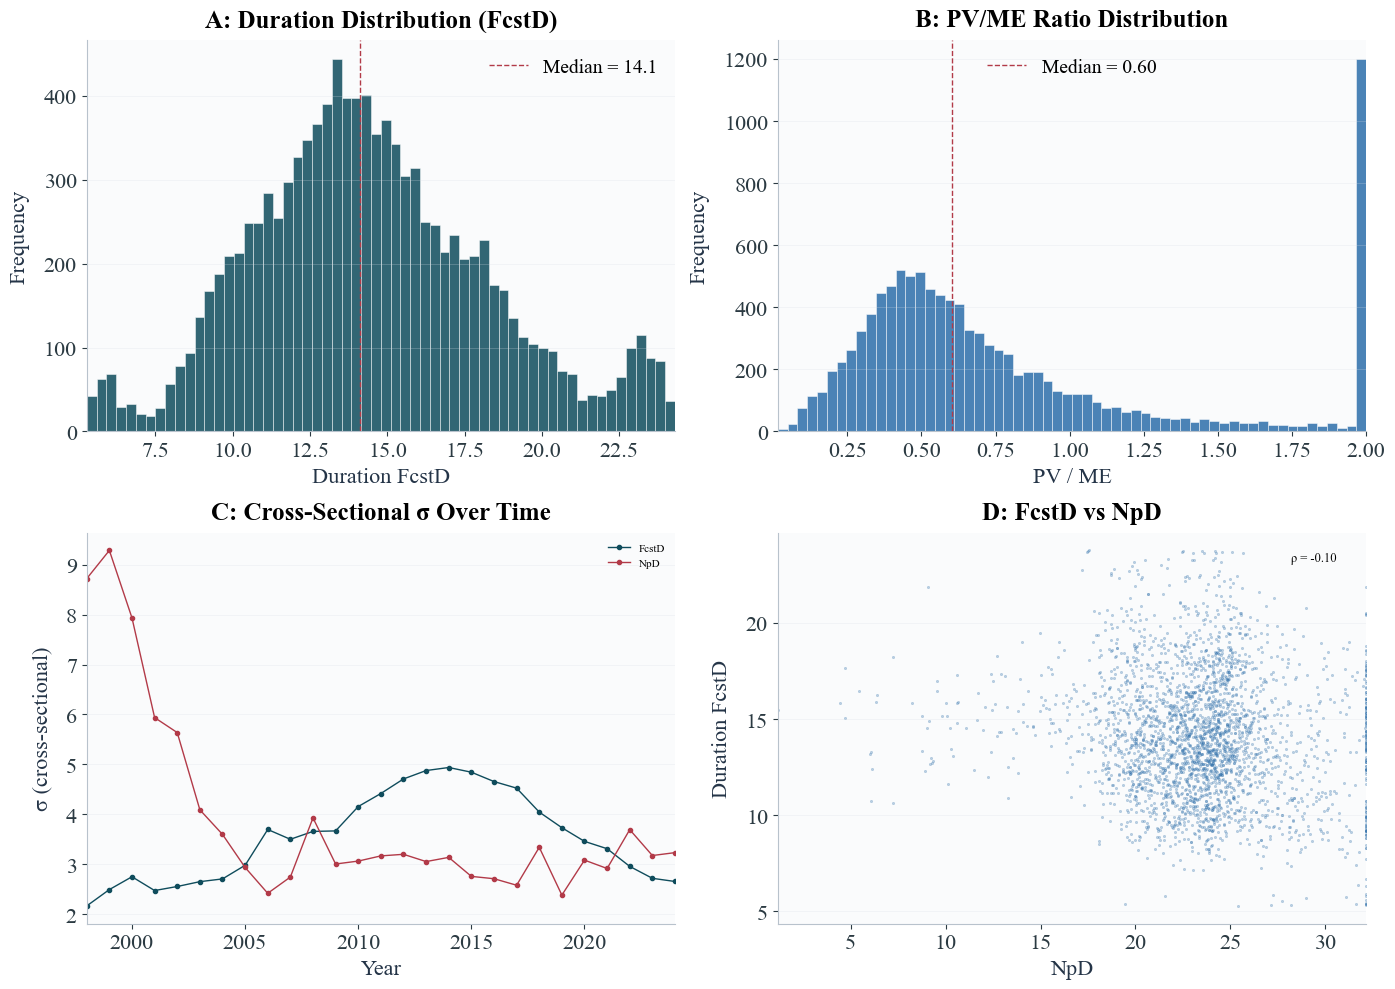

In [83]:
set_global_plot_style()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# A: Duration distribution
fcstd_valid = df[df["Duration_FcstD"].notna() & df["Duration_FcstD"].notna()]
axes[0, 0].hist(fcstd_valid["Duration_FcstD"], bins=60, color=COLORS["primary"], edgecolor="white", alpha=0.85)
axes[0, 0].set_xlabel("Duration FcstD")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("A: Duration Distribution (FcstD)")
axes[0, 0].axvline(fcstd_valid["Duration_FcstD"].median(), color=COLORS["accent"], ls="--",
                    label=f'Median = {fcstd_valid["Duration_FcstD"].median():.1f}')
axes[0, 0].legend(frameon=False)
style_axes(axes[0, 0])

# B: PV/ME ratio distribution
pv_me = df.loc[df["Duration_FcstD"].notna(), "PV_forecast"] / df.loc[df["Duration_FcstD"].notna(), "ME"]
axes[0, 1].hist(pv_me.clip(0, 2), bins=60, color=COLORS["blue"], edgecolor="white", alpha=0.85)
axes[0, 1].set_xlabel("PV / ME")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("B: PV/ME Ratio Distribution")
axes[0, 1].axvline(pv_me.median(), color=COLORS["accent"], ls="--",
                    label=f'Median = {pv_me.median():.2f}')
axes[0, 1].legend(frameon=False)
style_axes(axes[0, 1])

# C: σ over time
_np = load_parquet("EQDuration_Netpayout")[["firm_id", "date", "Duration_NetPayout"]]
_mg = df.merge(_np, on=["firm_id", "date"], how="left")
for label, col, color in [
    ("FcstD", "Duration_FcstD", COLORS["primary"]),
    ("NpD", "Duration_NetPayout", COLORS["accent"]),
]:
    if col in _mg.columns:
        ys = _mg.groupby("year")[col].std()
        axes[1, 0].plot(ys.index, ys.values, marker="o", ms=3, label=label, color=color)
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("σ (cross-sectional)")
axes[1, 0].set_title("C: Cross-Sectional σ Over Time")
axes[1, 0].legend(frameon=False, fontsize=8)
style_axes(axes[1, 0])

# D: FcstD vs NpD scatter
_sc_np = _mg[_mg["Duration_FcstD"].notna() & _mg["Duration_NetPayout"].notna()
             ].copy()
if len(_sc_np) > 3000:
    _sc_np_plot = _sc_np.sample(3000, random_state=42)
else:
    _sc_np_plot = _sc_np
from scipy.stats import spearmanr as _sp
_rho_np, _ = _sp(_sc_np["Duration_FcstD"], _sc_np["Duration_NetPayout"])
axes[1, 1].scatter(_sc_np_plot["Duration_NetPayout"], _sc_np_plot["Duration_FcstD"],
                   s=3, alpha=0.3, color=COLORS["blue"])
axes[1, 1].set_xlabel("NpD")
axes[1, 1].set_ylabel("Duration FcstD")
axes[1, 1].set_title("D: FcstD vs NpD")
axes[1, 1].text(0.95, 0.95, f"ρ = {_rho_np:+.2f}",
                transform=axes[1, 1].transAxes, ha="right", va="top", fontsize=9)
style_axes(axes[1, 1])

fig.tight_layout()
save_figure(fig, "fcstd_diagnostics")
plt.show()

In [84]:
# FcstD Duration — Summary
print("=" * 70)
print("FcstD Duration — SUMMARY (WAM over explicit CFs, r=0.08, H=20)")
print("=" * 70)

# 1. Industry ROE
print("\n1. Industry ROE (trailing 5-year trimmed mean):")
ind_roe = df.groupby("trbc_sector")["industry_roe_used"].agg(["mean", "median"])
print(ind_roe.to_string(float_format=lambda x: f"{x:.3f}"))

# 2. Sample
valid = df["Duration_FcstD"].notna()
n_valid = valid.sum()
print(f"\n2. Sample: {n_valid:,} / {len(df):,} ({n_valid/len(df):.1%})")

# 3. Duration stats
print("\n3. Duration (FcstD):")
from scipy.stats import spearmanr
_np = load_parquet("EQDuration_Netpayout")[["firm_id", "date", "Duration_NetPayout"]]
_mg = df.merge(_np, on=["firm_id", "date"], how="left")
_sub = _mg[_mg["Duration_FcstD"].notna()].copy()
dur = _sub["Duration_FcstD"]
print(f"   Mean: {dur.mean():.2f}, Median: {dur.median():.2f}, Std: {dur.std():.2f}")
print(f"   P5: {dur.quantile(0.05):.2f}, P95: {dur.quantile(0.95):.2f}")
print(f"   avg σ (by year): {_mg.groupby('year')['Duration_FcstD'].std().mean():.3f}")

# Correlations
_both = _sub.dropna(subset=["Duration_NetPayout"])
if len(_both) > 50:
    rho_np, _ = spearmanr(_both["Duration_FcstD"], _both["Duration_NetPayout"])
    print(f"   ρ(FcstD, NpD) = {rho_np:+.3f} (n={len(_both):,})")
_sub_ep = _sub.dropna(subset=["ROE_fy1"])
if len(_sub_ep) > 50:
    rho_ep, _ = spearmanr(_sub_ep["Duration_FcstD"], _sub_ep["ROE_fy1"])
    print(f"   ρ(FcstD, E/P) = {rho_ep:+.3f}")
_sub["BM"] = _sub["BE"] / _sub["ME"]
rho_bm, _ = spearmanr(_sub["Duration_FcstD"], _sub["BM"])
print(f"   ρ(FcstD, B/M) = {rho_bm:+.3f}")

# 4. PV/ME and TV share
pv_me = df.loc[valid, "PV_forecast"] / df.loc[valid, "ME"]
tv_share = df.loc[valid, "TV"] / df.loc[valid, "ME"]
print(f"\n4. PV/ME: mean={pv_me.mean():.1%}, median={pv_me.median():.1%}")
print(f"   TV share: mean={tv_share.mean():.1%}, median={tv_share.median():.1%}")
print(f"   TV=0 (PV≥ME): {(df.loc[valid, 'TV'] == 0).sum():,} ({(df.loc[valid, 'TV'] == 0).mean():.1%})")

print("\n" + "=" * 70)

FcstD Duration — SUMMARY (WAM over explicit CFs, r=0.08, H=20)

1. Industry ROE (trailing 5-year trimmed mean):
                                            mean  median
trbc_sector                                             
Basic Materials                            0.112   0.116
Consumer Cyclicals                         0.166   0.163
Consumer Non-Cyclicals                     0.294   0.225
Energy                                     0.210   0.172
Financials                                 0.239   0.126
Healthcare                                 0.199   0.201
Industrials                                0.149   0.151
Institutions, Associations & Organizations 0.500   0.500
Real Estate                                0.088   0.086
Technology                                 0.218   0.224
Utilities                                  0.110   0.114

2. Sample: 10,811 / 10,813 (100.0%)

3. Duration (FcstD):
   Mean: 14.45, Median: 14.13, Std: 3.82
   P5: 8.79, P95: 22.05
   avg σ (by year): 3.5

## 8. Distribution Diagnostics

### 8.1 Sample Funnel

In [85]:
print("Sample Funnel:")
print(funnel_df.to_string(index=False))

Sample Funnel:
                        Step  Firm-years  Dropped
                   Raw input       13500        0
                year >= 1998       13500        0
        NumAnalysts_fy1 >= 3       11273     2227
         EPS_fy1_est not NaN       11269        4
BE > 0 & ME > 0 & shares > 0       11002      267
        FY2/FY3 not negative       10813      189


### 8.2 Duration Distribution

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/duration_fcstd_distribution.png


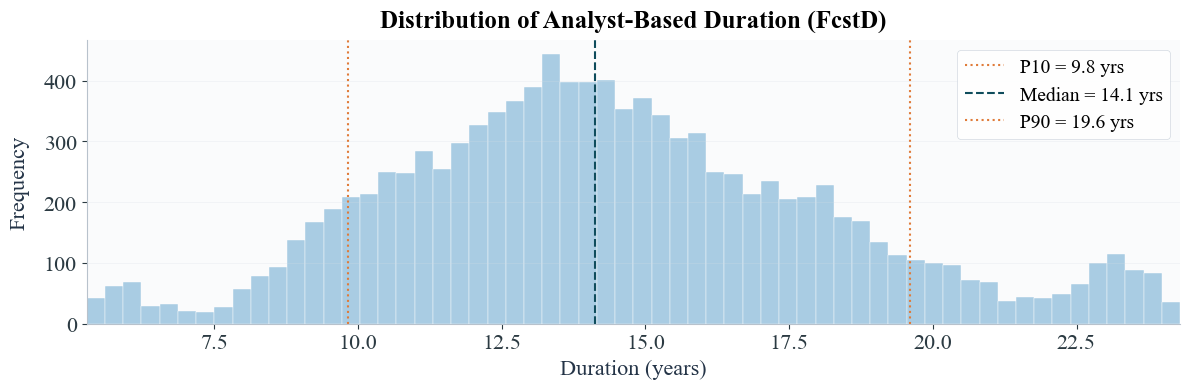

In [86]:
set_global_plot_style()

dur_plot = out.loc[out["Duration_FcstD"].notna(), "Duration_FcstD"].dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(dur_plot, bins=60, color=COLORS["blue_light"],
        edgecolor="white", linewidth=0.3, density=False)

_p10 = dur_plot.quantile(0.10)
_p50 = dur_plot.quantile(0.50)
_p90 = dur_plot.quantile(0.90)

ax.axvline(_p10, color=COLORS.get("coral", "#e07b39"),
           lw=1.5, ls=":",
           label=f"P10 = {_p10:.1f} yrs")
ax.axvline(_p50, color=COLORS.get("primary", "#1f4e79"),
           lw=1.5, ls="--",
           label=f"Median = {_p50:.1f} yrs")
ax.axvline(_p90, color=COLORS.get("coral", "#e07b39"),
           lw=1.5, ls=":",
           label=f"P90 = {_p90:.1f} yrs")

ax.set_title("Distribution of Analyst-Based Duration (FcstD)")
ax.set_xlabel("Duration (years)")
ax.set_ylabel("Frequency")
ax.legend(frameon=True)
style_axes(ax)
plt.tight_layout()
save_figure(fig, "duration_fcstd_distribution")
plt.show()


### 8.3 Duration Over Time

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/duration_fcstd_over_time.png


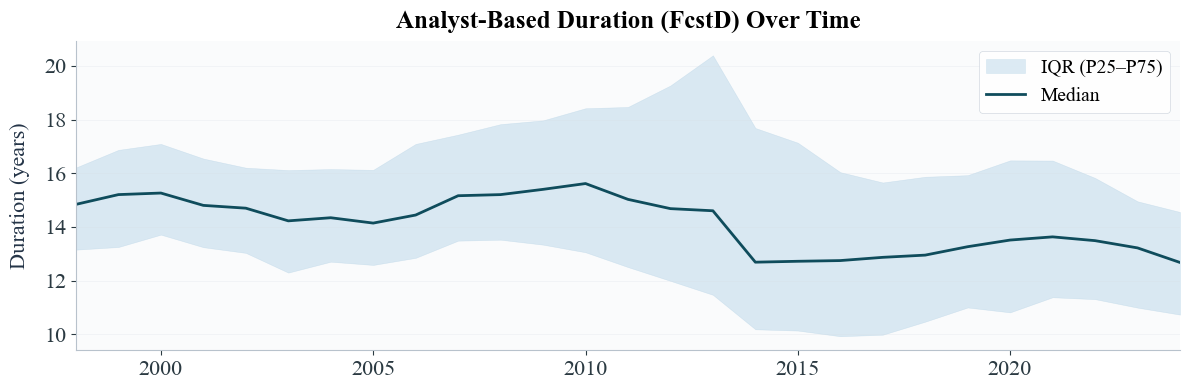

In [87]:
set_global_plot_style()

usable = out.loc[out["Duration_FcstD"].notna()].copy()
usable["year"] = usable["date"].dt.year

time_stats = usable.groupby("year")["Duration_FcstD"].agg(
    median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
).reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(time_stats["year"], time_stats["q25"], time_stats["q75"],
                color=COLORS["blue_light"], alpha=0.4, label="IQR (P25–P75)")
ax.plot(time_stats["year"], time_stats["median"],
        color=COLORS["primary"], lw=2.0, label="Median")

ax.set_title("Analyst-Based Duration (FcstD) Over Time")
ax.set_xlabel("")
ax.set_ylabel("Duration (years)")
ax.set_xlim(1998, usable["year"].max())
style_axes(ax)
ax.legend(loc="upper right", frameon=True, facecolor=(1,1,1,0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "duration_fcstd_over_time")
plt.show()

### 8.4 Decile Analysis

Firms sorted into 10 deciles by Duration_FcstD each year. We report
mean fundamentals per decile to verify economic plausibility.

In [88]:
dec = usable.copy()
dec["payout_yield"] = (
    dec["DPS_fy1_est"] * dec["shares_outstanding"] / dec["ME"]
)

dec["dur_decile"] = dec.groupby("year")["Duration_FcstD"].transform(
    lambda x: pd.qcut(x, 10, labels=range(1, 11), duplicates="drop")
)
dec["dur_decile"] = pd.to_numeric(dec["dur_decile"], errors="coerce")

decile_table = (
    dec.groupby("dur_decile")
    .agg(
        mean_duration=("Duration_FcstD", "mean"),
        mean_payout_yield=("payout_yield", "mean"),
        n_obs=("Duration_FcstD", "count"),
    )
    .reset_index()
)
decile_table["mean_payout_yield"] = decile_table["mean_payout_yield"] * 100  # percent

print("Decile Analysis: Duration vs Payout Yield")
print(decile_table.to_string(index=False, float_format="{:.2f}".format))

Decile Analysis: Duration vs Payout Yield
 dur_decile  mean_duration  mean_payout_yield  n_obs
          1           8.86               6.08   1092
          2          10.74               5.06   1080
          3          11.87               4.13   1077
          4          12.73               3.57   1079
          5          13.61               3.33   1085
          6          14.52               2.74   1073
          7          15.53               3.52   1077
          8          16.88               4.49   1079
          9          18.63             182.51   1078
         10          21.15            2220.87   1091


### 8.5 Correlation with Net-Payout Duration and Fundamentals

Convergent validity: FcstD vs NpD, E/P, B/M.

In [89]:
# Inspect columns before merge
print("out columns:", list(out.columns))
print("np_out Duration-like columns:", [c for c in np_out.columns if "uration" in c or "dur" in c.lower()])

# Merge with NetPayout duration
np_dur = np_out[["firm_id", "year", "Duration_NetPayout"]].copy()
np_dur = np_dur.rename(columns={"Duration_NetPayout": "Duration_NP"})

corr_df = out.copy()
corr_df["year"] = corr_df["date"].dt.year
corr_df = corr_df.merge(np_dur, on=["firm_id", "year"], how="left")

# Merge diagnostics
n_np_matched = corr_df["Duration_NP"].notna().sum()
n_total = len(corr_df)
print(f"\nMerge diagnostics:")
print(f"  Rows with non-null Duration_NP: {n_np_matched:,} / {n_total:,} ({n_np_matched/n_total:.1%})")

corr_usable_all = corr_df.loc[corr_df["Duration_FcstD"].notna()].copy()
n_usable_np = corr_usable_all["Duration_NP"].notna().sum()
n_usable = len(corr_usable_all)
print(f"  Usable FcstD sample with matched NP: {n_usable_np:,} / {n_usable:,} ({n_usable_np/n_usable:.1%})")

if n_usable_np / n_usable < 0.50:
    print(f"\n  ⚠ Coverage warning: Only {n_usable_np/n_usable:.1%} of usable FcstD firm-years")
    print(f"    have a matched NP duration. This is likely due to different sample periods")
    print(f"    or filter differences between the analyst-based and net-payout notebooks.")

# Construct additional variables
corr_df["BM"] = corr_df["BE"] / corr_df["ME"]
corr_df["EP"] = (corr_df["EPS_fy1_est"] * corr_df["shares_outstanding"]) / corr_df["ME"]
corr_df["log_ME"] = np.log(corr_df["ME"])

# Filter usable
corr_usable = corr_df.loc[corr_df["Duration_FcstD"].notna()].copy()

corr_vars = ["Duration_FcstD", "Duration_NP", "log_ME", "BM", "EP"]

# Pearson
corr_matrix = corr_usable[corr_vars].corr()
print("\nPearson Correlation Matrix (usable sample):")
print(corr_matrix.to_string(float_format="{:.3f}".format))

# Spearman
spearman = corr_usable[corr_vars].corr(method="spearman")
print("\nSpearman Rank Correlation:")
print(spearman.to_string(float_format="{:.3f}".format))

# Focal correlations
both_valid = corr_usable[["Duration_FcstD", "Duration_NP"]].dropna()
print(f"\nFocal: Corr(FcstD, NP) on {len(both_valid):,} overlapping firm-years:")
print(f"  Pearson:  {both_valid['Duration_FcstD'].corr(both_valid['Duration_NP']):.3f}")
print(f"  Spearman: {both_valid['Duration_FcstD'].corr(both_valid['Duration_NP'], method='spearman'):.3f}")

out columns: ['firm_id', 'date', 'year', 'trbc_sector', 'EPS_fy1_est', 'EPS_fy2_est', 'EPS_fy3_est', 'DPS_fy1_est', 'DPS_fy2_est', 'DPS_fy3_est', 'NumAnalysts_fy1', 'shares_outstanding', 'BE', 'ME', 'ROE_fy1', 'ROE_fy2', 'ROE_fy3', 'b_fy1', 'b_fy2', 'b_fy3', 'industry_roe_used', 'PV_forecast', 'TV', 'Duration_FcstD_raw', 'Duration_FcstD']
np_out Duration-like columns: ['Duration_NetPayout', 'Duration_NP_strict', 'duration_usable', 'duration_usable_strict']

Merge diagnostics:
  Rows with non-null Duration_NP: 8,665 / 10,813 (80.1%)
  Usable FcstD sample with matched NP: 8,664 / 10,811 (80.1%)

Pearson Correlation Matrix (usable sample):
                Duration_FcstD  Duration_NP  log_ME     BM     EP
Duration_FcstD           1.000       -0.129  -0.052  0.008  0.045
Duration_NP             -0.129        1.000   0.164 -0.176 -0.038
log_ME                  -0.052        0.164   1.000 -0.081  0.000
BM                       0.008       -0.176  -0.081  1.000  0.006
EP                       

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/coverage_fcstd_annual.png


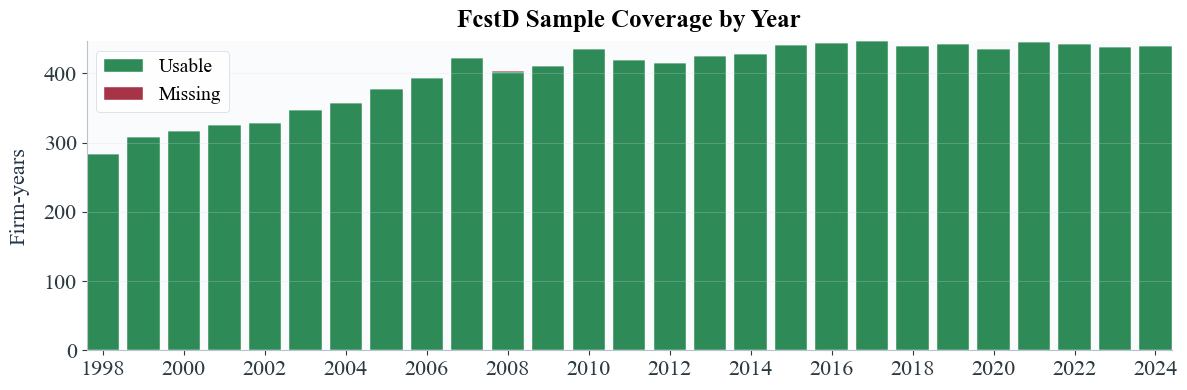

In [90]:
set_global_plot_style()

# Coverage by year
_cov = out.copy()
_cov["year"] = _cov["date"].dt.year
_cov_grp = (
    _cov.groupby("year")
    .agg(
        usable=("Duration_FcstD", lambda s: int(s.notna().sum())),
        missing=("Duration_FcstD", lambda s: int(s.isna().sum())),
    )
    .reset_index()
)
_cov_grp = _cov_grp[(_cov_grp["year"] >= 1998) & (_cov_grp["year"] <= 2024)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(_cov_grp["year"], _cov_grp["usable"],
       color=COLORS["green"], edgecolor="white", linewidth=0.3,
       label="Usable")
ax.bar(_cov_grp["year"], _cov_grp["missing"],
       bottom=_cov_grp["usable"],
       color=COLORS["red"], edgecolor="white", linewidth=0.3,
       label="Missing")

ax.set_title("FcstD Sample Coverage by Year")
ax.set_xlabel("")
ax.set_ylabel("Firm-years")
ax.set_xticks(range(1998, 2025, 2))
style_axes(ax)
ax.legend(loc="upper left", frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "coverage_fcstd_annual")
plt.show()

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/tv_share_fcstd_hist.png


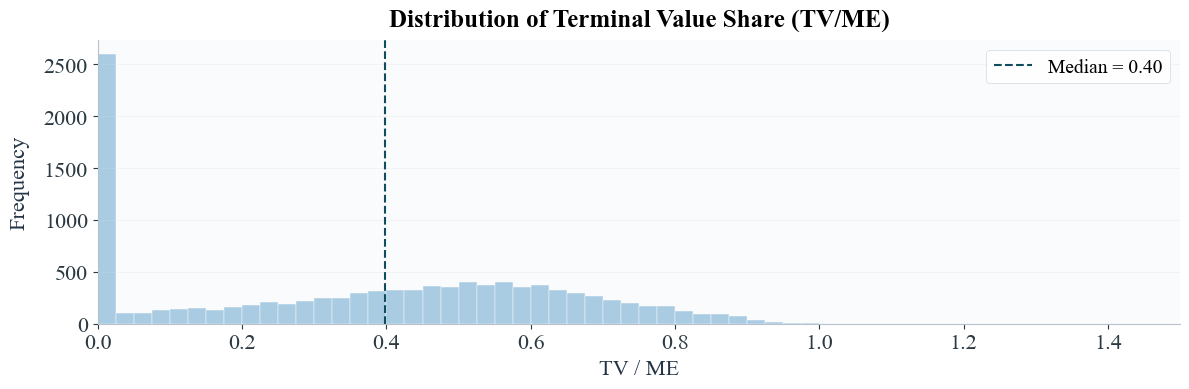

In [91]:
set_global_plot_style()

# Terminal value share: TV / ME for usable observations
_tv = out.loc[out["Duration_FcstD"].notna(), ["TV", "ME"]].dropna()
_tv_share = (_tv["TV"] / _tv["ME"]).replace([np.inf, -np.inf], np.nan).dropna()
_tv_share_clip = _tv_share.clip(lower=0.0, upper=1.5)
_median_tv = _tv_share.median()

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(_tv_share_clip, bins=60, range=(0.0, 1.5),
        color=COLORS["blue_light"], edgecolor="white", linewidth=0.3)
ax.axvline(_median_tv, color=COLORS["primary"], lw=1.5, ls="--",
           label=f"Median = {_median_tv:.2f}")

ax.set_title("Distribution of Terminal Value Share (TV/ME)")
ax.set_xlabel("TV / ME")
ax.set_ylabel("Frequency")
ax.set_xlim(0.0, 1.5)
style_axes(ax)
ax.legend(loc="upper right", frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "tv_share_fcstd_hist")
plt.show()


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/fcstd_decile_payout_yield.png


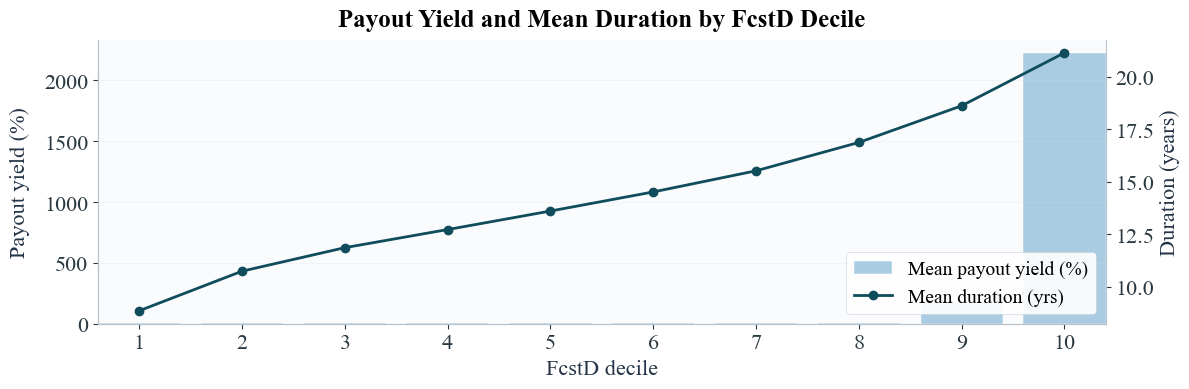

In [92]:
set_global_plot_style()

# Use existing `dec` DataFrame from Cell 22 decile analysis
_dec_plot = (
    dec.dropna(subset=["dur_decile"])
    .groupby("dur_decile")
    .agg(
        mean_duration=("Duration_FcstD", "mean"),
        mean_payout_yield=("payout_yield", "mean"),
    )
    .reset_index()
)
_dec_plot["mean_payout_yield_pct"] = _dec_plot["mean_payout_yield"] * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(_dec_plot["dur_decile"], _dec_plot["mean_payout_yield_pct"],
       color=COLORS["blue_light"], edgecolor="white", linewidth=0.3,
       label="Mean payout yield (%)")
ax.set_xlabel("FcstD decile")
ax.set_ylabel("Payout yield (%)")
ax.set_xticks(range(1, 11))
style_axes(ax)

ax2 = ax.twinx()
ax2.plot(_dec_plot["dur_decile"], _dec_plot["mean_duration"],
         color=COLORS["primary"], lw=2.0, marker="o",
         label="Mean duration (yrs)")
ax2.set_ylabel("Duration (years)")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_color("#B8C2CC")
ax2.tick_params(axis="y", labelsize=16)

ax.set_title("Payout Yield and Mean Duration by FcstD Decile")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="lower right",
          frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "fcstd_decile_payout_yield")
plt.show()


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/fcstd_npd_scatter.png


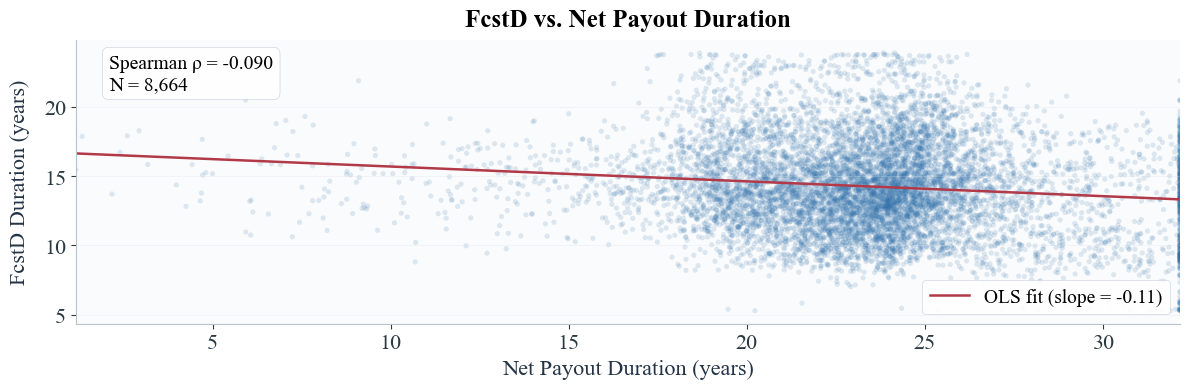

In [93]:
set_global_plot_style()

# Scatter FcstD vs NpD using corr_df from Cell 24
_sc = corr_df.loc[corr_df["Duration_FcstD"].notna(), ["Duration_FcstD", "Duration_NP"]].dropna()

_rho_s = _sc["Duration_FcstD"].corr(_sc["Duration_NP"], method="spearman")

# Linear regression line
_x = _sc["Duration_NP"].values
_y = _sc["Duration_FcstD"].values
_slope, _intercept = np.polyfit(_x, _y, 1)
_x_line = np.linspace(_x.min(), _x.max(), 100)
_y_line = _slope * _x_line + _intercept

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(_sc["Duration_NP"], _sc["Duration_FcstD"],
           alpha=0.15, s=14, color=COLORS["blue"],
           edgecolors="none")
ax.plot(_x_line, _y_line, color=COLORS["accent"], lw=1.8,
        label=f"OLS fit (slope = {_slope:.2f})")

ax.text(0.03, 0.95,
        f"Spearman ρ = {_rho_s:.3f}\nN = {len(_sc):,}",
        transform=ax.transAxes, va="top", ha="left",
        fontsize=14,
        bbox=dict(boxstyle="round,pad=0.35",
                  facecolor=(1, 1, 1, 0.82),
                  edgecolor="#C4CDD7"))

ax.set_title("FcstD vs. Net Payout Duration")
ax.set_xlabel("Net Payout Duration (years)")
ax.set_ylabel("FcstD Duration (years)")
style_axes(ax)
ax.legend(loc="lower right", frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "fcstd_npd_scatter")
plt.show()


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/roe_reversion_example.png


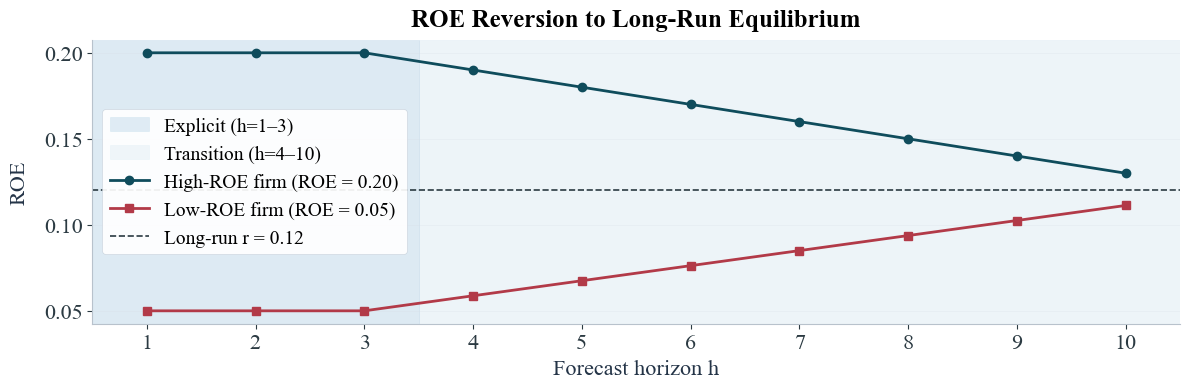

In [94]:
set_global_plot_style()

# Illustrative ROE reversion schematic
_r_bar = 0.12
_h = np.arange(1, 11)

def _roe_path(roe0: float) -> np.ndarray:
    path = np.empty_like(_h, dtype=float)
    for i, h in enumerate(_h):
        if h <= 3:
            path[i] = roe0
        else:
            alpha = (h - 3) / 8.0
            path[i] = (1 - alpha) * roe0 + alpha * _r_bar
    return path

_high = _roe_path(0.20)
_low = _roe_path(0.05)

fig, ax = plt.subplots(figsize=(12, 4))

# Shaded regions
ax.axvspan(0.5, 3.5, color=COLORS["blue_light"], alpha=0.35, label="Explicit (h=1–3)")
ax.axvspan(3.5, 10.5, color=COLORS["blue_light"], alpha=0.15, label="Transition (h=4–10)")

ax.plot(_h, _high, color=COLORS["primary"], lw=2.0, marker="o",
        label="High-ROE firm (ROE = 0.20)")
ax.plot(_h, _low, color=COLORS["accent"], lw=2.0, marker="s",
        label="Low-ROE firm (ROE = 0.05)")

ax.axhline(_r_bar, color=COLORS["reference"], lw=1.2, ls="--",
           label=f"Long-run r = {_r_bar:.2f}")

ax.set_title("ROE Reversion to Long-Run Equilibrium")
ax.set_xlabel("Forecast horizon h")
ax.set_ylabel("ROE")
ax.set_xticks(_h)
ax.set_xlim(0.5, 10.5)
style_axes(ax)
ax.legend(loc="center left", frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "roe_reversion_example")
plt.show()


In [95]:
# GRAFIK-ÜBERSICHT: FcstD figures
_fcstd_figs = [
    "duration_fcstd_distribution",
    "duration_fcstd_over_time",
    "coverage_fcstd_annual",
    "tv_share_fcstd_hist",
    "fcstd_decile_payout_yield",
    "fcstd_npd_scatter",
    "roe_reversion_example",
]

print("GRAFIK-ÜBERSICHT – EQDuration_AnalystBased")
print(f"Directory: {NOTEBOOK_GRAPH_DIR}")
print("-" * 60)
for _name in _fcstd_figs:
    _p = NOTEBOOK_GRAPH_DIR / f"{_name}.png"
    _mark = "✓" if _p.exists() else "✗"
    print(f"  [{_mark}] {_name}.png")
print("-" * 60)
_n_ok = sum((NOTEBOOK_GRAPH_DIR / f"{n}.png").exists() for n in _fcstd_figs)
print(f"Total: {_n_ok}/{len(_fcstd_figs)} figures present")


GRAFIK-ÜBERSICHT – EQDuration_AnalystBased
Directory: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased
------------------------------------------------------------
  [✓] duration_fcstd_distribution.png
  [✓] duration_fcstd_over_time.png
  [✓] coverage_fcstd_annual.png
  [✓] tv_share_fcstd_hist.png
  [✓] fcstd_decile_payout_yield.png
  [✓] fcstd_npd_scatter.png
  [✓] roe_reversion_example.png
------------------------------------------------------------
Total: 7/7 figures present


## 9. Summary Statistics

In [96]:
usable_final = out.loc[out["Duration_FcstD"].notna()].copy()
dur = usable_final["Duration_FcstD"].dropna()

print("=" * 50)
print("FINAL SUMMARY")
print("=" * 50)
print(f"Output shape:       {out.shape}")
print(f"Usable firm-years:  {len(usable_final):,} / {len(out):,} ({len(usable_final)/len(out):.1%})")
print(f"Missing rate:       {out['Duration_FcstD'].isna().mean():.1%}")
print(f"\nDuration_FcstD percentiles (usable sample):")
for p_val, label in [(0.10, "P10"), (0.25, "P25"), (0.50, "P50"), (0.75, "P75"), (0.90, "P90")]:
    print(f"  {label}: {dur.quantile(p_val):.2f}")
print(f"  Mean: {dur.mean():.2f}")
print(f"  Std:  {dur.std():.2f}")

FINAL SUMMARY
Output shape:       (10813, 25)
Usable firm-years:  10,811 / 10,813 (100.0%)
Missing rate:       0.0%

Duration_FcstD percentiles (usable sample):
  P10: 9.82
  P25: 11.86
  P50: 14.13
  P75: 16.80
  P90: 19.60
  Mean: 14.45
  Std:  3.82
